# EXERCISE 07: Montecarlo simulation of LJ system

## 07.1
**In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.**

I implemented the tail corrections in the *initialize_properties()* function:

**potential energy correction:**
```c++
        _vtail = A/double(9*pow(_r_cut,9))-A/double(3*pow(_r_cut,3)); 

**pressure correction**
```c++
        _ptail = (32.*M_PI*_rho)*(1./double(9*pow(_r_cut,9))-1./double(6*pow(_r_cut,3))); 
       

The values I obtained are:
- vtail = -0.428346
- ptail = -0.855522

SCRIVERE VALORI DI VTAIL E PTAIL(DEVONO VENIRE CIRCA 0.5), CORREGGERE EX4 TOGLIENDO TAIL CORRECTION

## 07.2
### Exercise 07.2

<b>Use the NSL simulator code to <span style="color:red">print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations</span> of $M=5\times 10^5$ MC steps or MD time steps in the following thermodynamic conditions:<b>
- **liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)**
1. <b>Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. <b>Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. <span style="color:red">Make pictures of these statistical uncertainties as a function of $L$.</span> What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

### Preliminary analysis
#### MC ACCEPTANCE
In order to obtain correct results with the MC method, my first step was to determine the optimal step_length to obtain an acceotance of 50%. To do so I performed 10 simple simulations in which I let the system evolve for 5000 steps and determined the acceptance rate.

#### EQUILIBRATION 
To equilibrate the system, I tried different starting temperatures and let the system evolve for 3000 steps. I determined that stOptimal starting temperature is 1.97,since the temperature becomes well stabilized around the desired value. From the following plot I also deduced that 1500 steps are sufficient to reach stability.

Therefore I chose dt=0.16

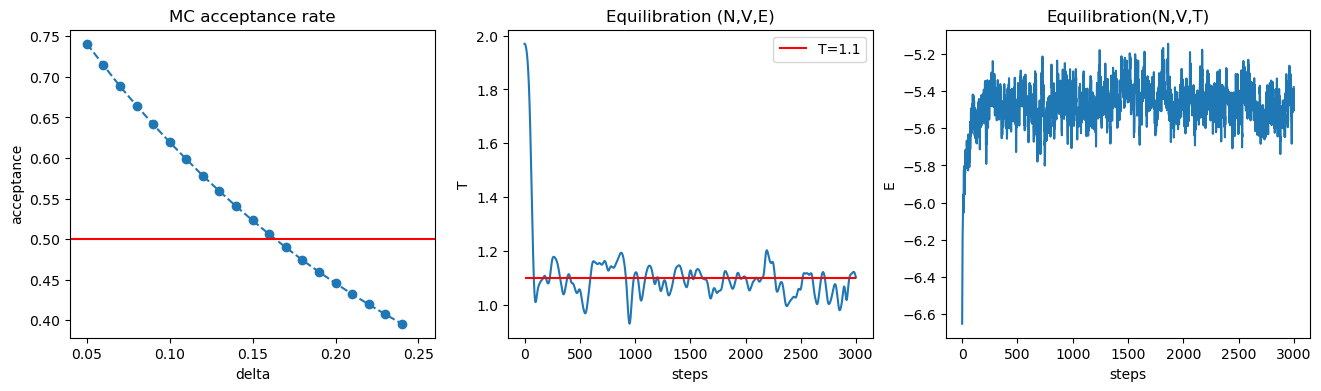

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
file= "./OUTPUT/Equilibration_MD.csv"
df1 = pd.read_csv(file,sep ="\t")
file= "./OUTPUT/Equilibration_MC.csv"
df2 = pd.read_csv(file,sep ="\t")
Neq_steps=len(df1['Step'])

file= "./OUTPUT/acceptance_tries.csv"
df =pd.read_csv(file,sep ='\t')

fig,ax = plt.subplots(1,3,figsize=(16,4))
ax[0].plot(df['DELTA'],df['ACCEPTANCE'],marker ='o', linestyle='dashed')
ax[0].hlines(0.5,0.04,0.26, color= 'red')
ax[0].set_xlabel('delta')
ax[0].set_ylabel('acceptance')
ax[0].set_xlim(0.04,0.26)
ax[0].set_title('MC acceptance rate')
ax[1].plot(df1['Step'],df1['Temp'])
ax[1].hlines(1.1,0,Neq_steps,color='r',label = 'T=1.1')
ax[1].set_xlabel('steps')
ax[1].set_ylabel('T')
ax[1].legend()
ax[1].set_title(f'Equilibration (N,V,E)')

ax[2].plot(df2['Step'],df2['Energy'])
ax[2].set_xlabel('steps')
ax[2].set_ylabel('E')
ax[2].set_title(f'Equilibration(N,V,T)')

plt.show()

#### U/N AUTOCORRELATION

After the 1500 equilibration steps in which I don't make any measurements, I performed 500000 steps of MD and MC to obtain the instant values of $\frac{U}{N}$

The autocorrelation function for a finite set of MC time steps can be computed as :
$$\chi(t) = \frac{\frac{\sum_{t'=0}^{t_{max}-t}f(t')f(t'+t)}{t_{max}-t}-\frac{\Big(\sum_{t'=0}^{t_{max}-t}f(t')\Big)\Big(\sum_{t'=0}^{t_{max}-t}f(t'+t)\Big)}{(t_{max}-t)^2}}{\frac{\sum_{t'=0}^{t_{max}}f^2(t')}{t_{max}}-\Big(\frac{\sum_{t'=0}^{t_{max}}f(t')}{t_{max}}\Big)^2} = \frac{\langle f(t'<t)f(t<t'<t_{max})\rangle -\langle f(t'<t)\rangle \langle f(t<t'<t_{max})\rangle}{\langle f^2(t')\rangle -(\langle f(t') \rangle )^2}$$ 

In [3]:
import numpy as np

def autocorrelation (data, t:int,tmax:int):
    sum1 = np.sum(data[:(tmax-t)]*data[t:tmax])
    sum2 = np.sum(data[:tmax-t])
    sum3= np.sum(data[t:tmax])
    var = (np.sum(data**2)/(tmax))-((np.sum(data)/(tmax))**2)
    #var = np.mean(data**2)-(np.mean(data))**2
    chi=(sum1/(tmax-t)-(sum2*sum3)/((tmax-t)**2))/var

    if (np.isnan(chi)): return 0
    else :return chi
    #return (sum1-sum2*sum3)/var

def evaluate_chi(sim_type,len_t):
    file= (f"./OUTPUT/potential_energy_{sim_type}_instant.csv")
    df = pd.read_csv(file,sep = '\t')

    Ndata = len(df)

    nt = int(Ndata/len_t)

    data = np.array(df['ACTUAL_PE'])
    times = df['BLOCK'][::len_t]
    tmax = df['BLOCK'][int(Ndata-1)]
    chi =np.zeros(len(times))
    with open(f"./OUTPUT/chi{sim_type}.csv","w") as out:
        out.write("time\tchi\n")
        for i,t in enumerate(times):
            t_index = len_t *i
            chi[i] = autocorrelation(data,t,tmax)
            out.write(f'{t}\t{chi[i]}\n')
        out.close()
        
def model(x,tc): 
    return np.exp(-x/tc)

I computed the autocorrelationfor both (N,V,E) and (N,V,T) simulation for 5000 time values evenly spaced in the time interval (0,500000). I expect it to approach zero exponentially with a a characteristic time $\tau_c$, which can be estimated by fitting the measured autocorrelations with the function:
$$\chi(t)=e^{\frac{t}{\tau_c}}$$
A good rule to define the minimum length of the simulation blocks is that they have to be larger of the autocorrelation time, so that the block averages can really be considered statistically independent.

In [4]:
import pandas as pd

len_t=100
evaluate_chi("MD",len_t)
evaluate_chi("MC",len_t)

Data points: 500000, Autocorrelation commputed for 5000 time values (intervals of 100 points)
Data points: 500000, Autocorrelation commputed for 5000 time values (intervals of 100 points)


correlation time fit(NVE):[29.94468909]
correlation time fit(NVT):[4.86269379]


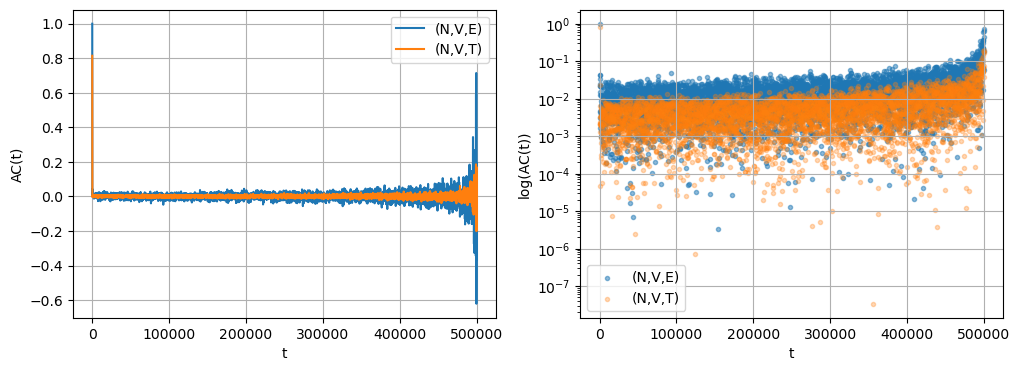

In [54]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


dfMD= pd.read_csv("./OUTPUT/chiMD.csv",sep='\t')
dfMC= pd.read_csv("./OUTPUT/chiMC.csv",sep='\t')

tc,tc_err = curve_fit(model,dfMD['time'],dfMD['chi'])
print(f'correlation time fit(NVE):{tc}')
tc1,tc_err1 = curve_fit(model,dfMC['time'],dfMC['chi'])
print(f'correlation time fit(NVT):{tc1}')
fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].plot(dfMD['time'],dfMD['chi'],label ='(N,V,E)')
ax[0].plot(dfMC['time'],dfMC['chi'],label ='(N,V,T)')
ax[0].legend()
ax[0].grid()

ax[0].set_xlabel('t')
ax[0].set_ylabel('AC(t)')

ax[1].scatter(dfMD['time'],abs(dfMD['chi']),marker='.',alpha=0.5,label ='(N,V,E)')
ax[1].scatter(dfMC['time'],abs(dfMC['chi']),marker='.',alpha =0.3,label='(N,V,T)')

ax[1].set_yscale('log')
#ax[0].set_xlim(0,2000)
ax[1].set_xlabel('t')
ax[1].set_ylabel('log(AC(t))')


ax[1].legend()
ax[1].grid()


#ax[0].plot(times/500,fit)

#### U/N BLOCK LENGTH

From these results we can conclude that the simulation blocks can be considered statistically independent even after few tens of steps. To confirm this I evaluated the statistical uncertainty of the block average of the $10^5$ U/N instant values for block lengths varying from 10 to 5000 steps. We can see that if the blocks are too small the error is very unstable, meanwhile it stabilizes  fast when the block length exceeds the autpcorroleation time. Also for the Montecarlo simulation this result s achieved faster (WHY?)

In [27]:
def estimate_stat_err(sim_type,n_L):
    L_values=np.linspace(10,5000,n_L+1,dtype=int)
    file= (f"./OUTPUT/potential_energy_{sim_type}_instant.csv")
    df = pd.read_csv(file,sep = '\t')
    blocks = np.array(df['BLOCK'])
    pe = np.array(df['ACTUAL_PE'])

    with open(f"./OUTPUT/stat_err{sim_type}.csv","w") as out:
    
        out.write("L\tblock_ave\terr\n")
        for L in L_values:
            Nblocks= int(len(blocks)/L)
            bl_ave=0
            bl_ave2=0
            for i in range(Nblocks):
                sub_pe = pe[i*L:i*L+L]
                ave= np.mean(sub_pe)
                bl_ave2+=ave*ave
                bl_ave += ave
    
            err=np.sqrt((bl_ave2/(Nblocks)-(bl_ave/Nblocks)**2)/(Nblocks-1))
    
            out.write(f"{L}\t{bl_ave/Nblocks}\t{err}\n")
        out.close()

In [36]:
estimate_stat_err('MD',1000)
estimate_stat_err('MC',1000)
   

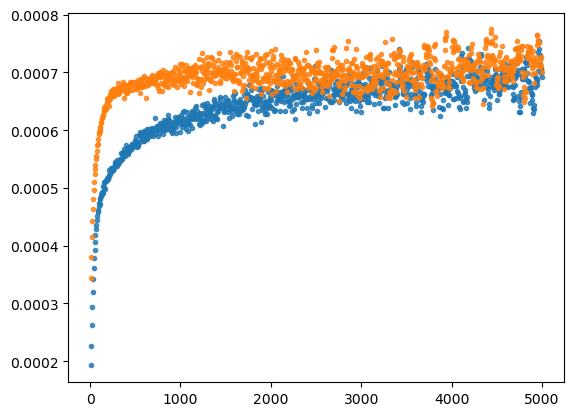

In [38]:
dfMD= pd.read_csv('./OUTPUT/stat_errMD.csv',sep='\t')
plt.scatter(dfMD['L'],dfMD['err'],marker='.',alpha=0.8)
dfMC= pd.read_csv('./OUTPUT/stat_errMC.csv',sep='\t')
plt.scatter(dfMC['L'],dfMC['err'],marker='.',alpha=0.8)

## 7.3
**Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code</span>: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.**

To measure $g(r)$ I divided $L/2$ in 100 bins and iterated over all possible particle pairs, incrementing each bin by two if the pair distance was found to be in it:
``` c++
  for (int i=0; i<_npart-1; i++){ 
      for (int j=i+1; j<_npart; j++){
       
        distance(0) = this->pbc( _particle(i).getposition(0,true) - _particle(j).getposition(0,true), 0);
        distance(1) = this->pbc( _particle(i).getposition(1,true) - _particle(j).getposition(1,true), 1);
        distance(2) = this->pbc( _particle(i).getposition(2,true) - _particle(j).getposition(2,true), 2);
        
        dr = sqrt( dot(distance,distance) );
        
        if(dr < _r_cut){
            if(_measure_gofr){
              for (int k=0; k<_n_bins;k++){
                if (dr> k*_bin_size && dr<(k+1)*_bin_size) _measurement(_index_gofr+k)+=2;
              }
        }}}

## 7.4
**By means of your upgraded NSL simulator code, equilibrate and perform MC NVT and MD NVE simulations via a Lennard-Jones model of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:**
- **liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)**

**show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ... and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.**

I used the method I showed before to measure $g(r)$ in 30 blocks of 2000 steps each, for both (N,V,E) and (N,V,T) simulations. I saved both the independent averages of each block" and the progressive averages. In the following plots I show the progressive average values and errors: we can see how $g(r)$ reproduces the expected distribution, and also that the MC simulation is more precose (lower errors).

In [85]:
def read_gofr_file(sim_type,block):
    if (block): file=f"./OUTPUT/gofr_blockave_{sim_type}.csv"
    else: file=f"./OUTPUT/gofr_{sim_type}.csv"
    df = pd.read_csv(file,sep ="\t", skiprows=1,skip_blank_lines = False)
    nan_rows = df[df.isnull().all(axis=1)].index

    split_points = [-1] + list(nan_rows) + [len(df)]

    histograms = []
    for i in range(len(split_points) - 1):
        start = split_points[i] + 1
        end = split_points[i + 1]
        block = df.iloc[start:end].reset_index(drop=True)
        if not block.empty:
            histograms.append(block)
    return histograms



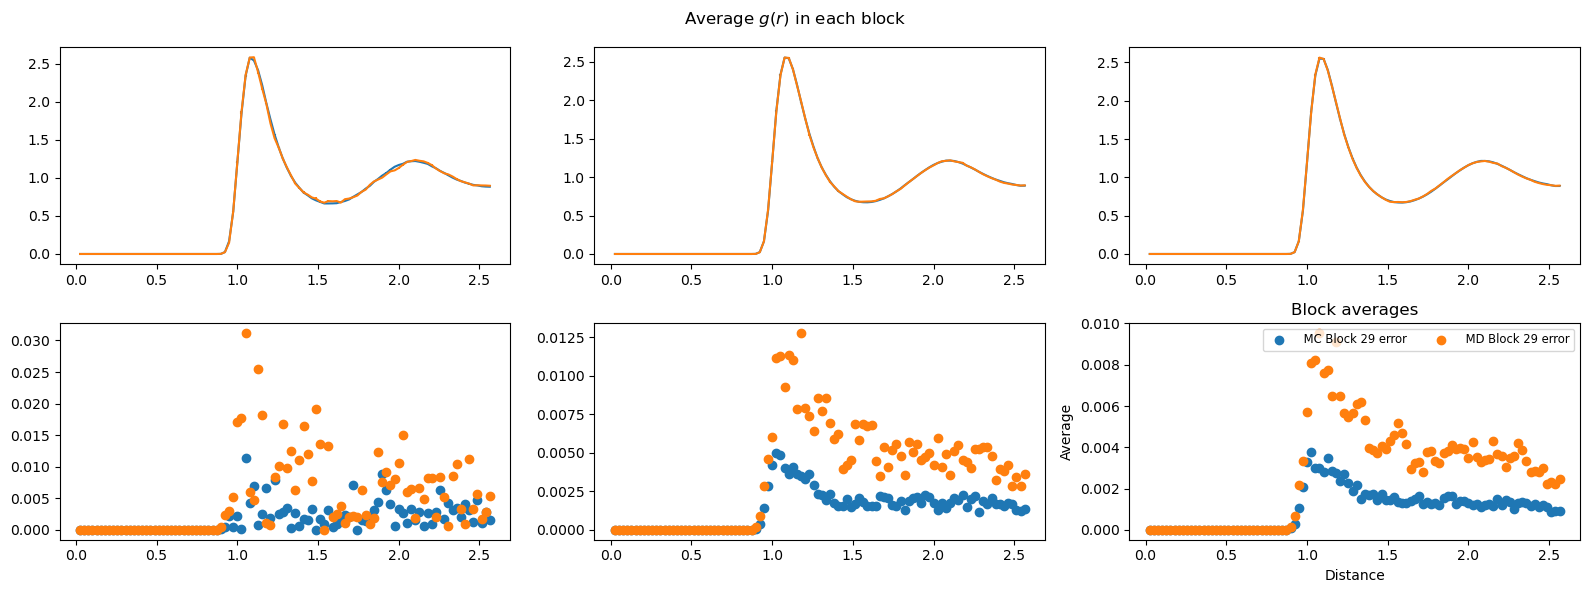

In [83]:
T=1.1
block=False
hist_MC = read_gofr_file('MC',block)
hist_MD =read_gofr_file('MD',block)

hist_to_plot=[1,15,29]
fig,ax = plt.subplots(2,len(hist_to_plot),figsize=(16,6))
for i,idx in enumerate(hist_to_plot):
    ax[0,i].errorbar(hist_MC[idx]['DISTANCE'], hist_MC[idx]['AVE_GOFR'], yerr=hist_MC[idx]['ERROR'],label=f' MC Block {idx}')
    ax[0,i].errorbar(hist_MD[idx]['DISTANCE'], hist_MD[idx]['AVE_GOFR'], yerr=hist_MD[idx]['ERROR'], label=f'MD Block {idx}')
    ax[1,i].scatter(hist_MC[idx]['DISTANCE'], hist_MC[idx]['ERROR'],label=f' MC Block {idx} error')
    ax[1,i].scatter(hist_MD[idx]['DISTANCE'], hist_MD[idx]['ERROR'],label=f' MD Block {idx} error')

plt.xlabel('Distance')
plt.ylabel('Average')
plt.title('Block averages')
fig.suptitle('Average $g(r)$ in each block')
plt.legend(fontsize='small', ncol=2)
plt.tight_layout()
plt.show()